In [1]:
import yaml
import numpy as np
from TraceSimulator import LongTraceSimulator
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.signal import fftconvolve


def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/home/dwong/DELight_mtr/trigger_study/archive/wk11/config.yaml')
lts = LongTraceSimulator(config)
def plot_traces(traces, fs=3_906_250, offset_step=70, title="QP Traces"):
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    plt.figure(figsize=(18, 12))
    
    for i in range(num_channels):
        color = 'orange' if i > 44 else 'tab:blue'
        plt.plot(time_ms, traces[i] + i * offset_step, lw=0.3, color=color)

    plt.xlabel("Time [ms]", fontsize=16)
    plt.ylabel("Offset ADC counts", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xlim(0, time_ms[-1])
    plt.ylim(-10, offset_step * (num_channels + 1))
    plt.yticks([])  # Hide y-axis ticks

    plt.tight_layout()
    plt.show()

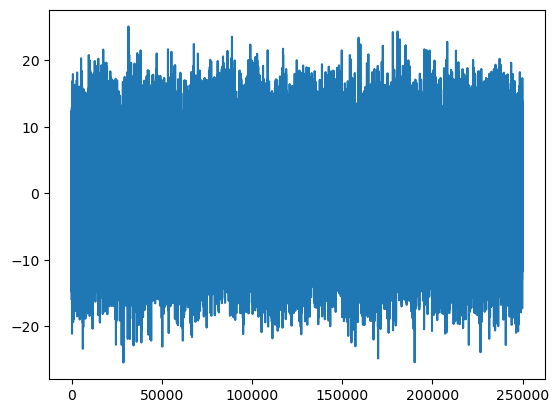

In [16]:
trace, idx= lts.generate(
            E=0,
            x=-94, y=0, z=-1800,
            no_noise=False,
            type_recoil='NR',
            quantize=False,
            phonon_only=False,
            long_trace_samples = 250000
        )
trace = trace[0]
example = trace[50]
plt.plot(example)

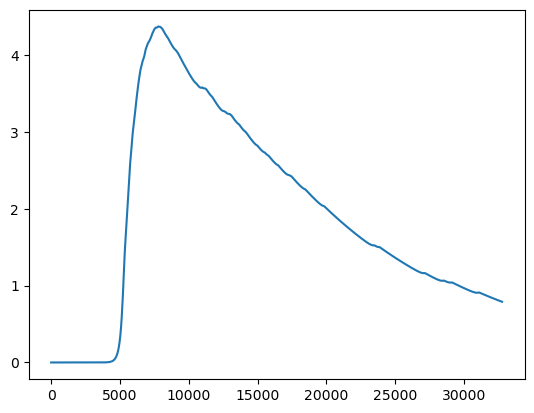

In [13]:
plt.plot(example[idx:idx+32768])

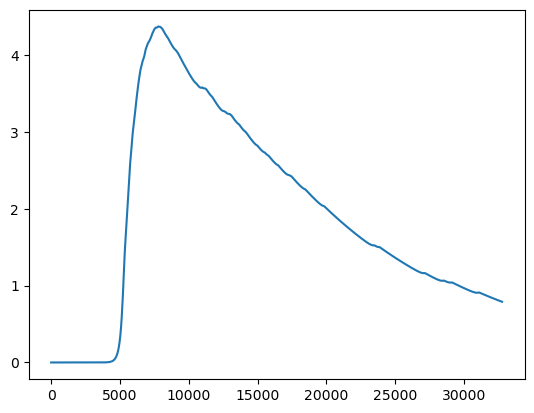

In [14]:
unquantized = trace[50]
plt.plot(unquantized[idx:idx+32768])

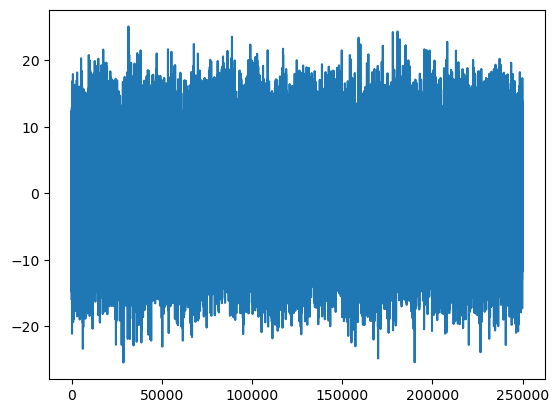

In [17]:
pure_noise = example
plt.plot(pure_noise)

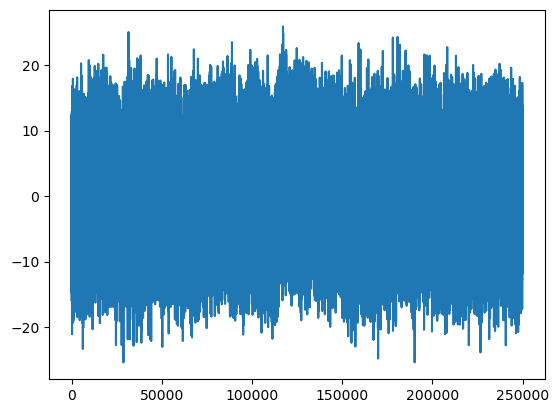

In [18]:
unquantized_sum = unquantized + pure_noise
plt.plot(unquantized_sum)

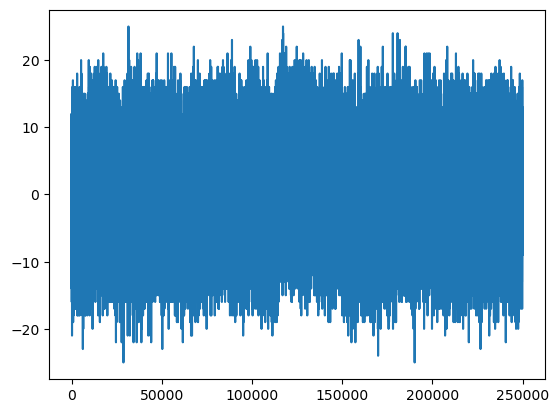

In [19]:
quantized_sum = np.array(unquantized_sum, dtype=int)
plt.plot(quantized_sum)

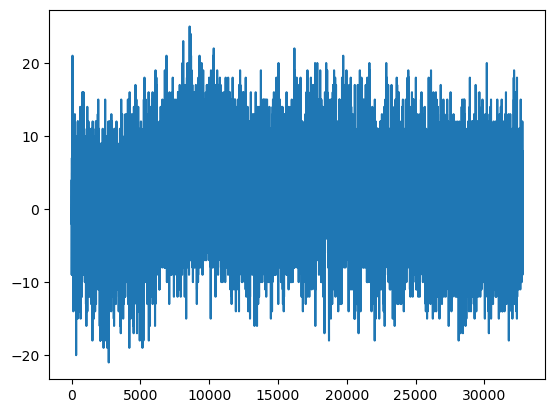

In [21]:
plt.plot(quantized_sum[idx:idx+32768])

In [22]:
np.savez("separate_trace.npz", signal=unquantized, noise=pure_noise, quantized=quantized_sum, unquantized=unquantized_sum)
